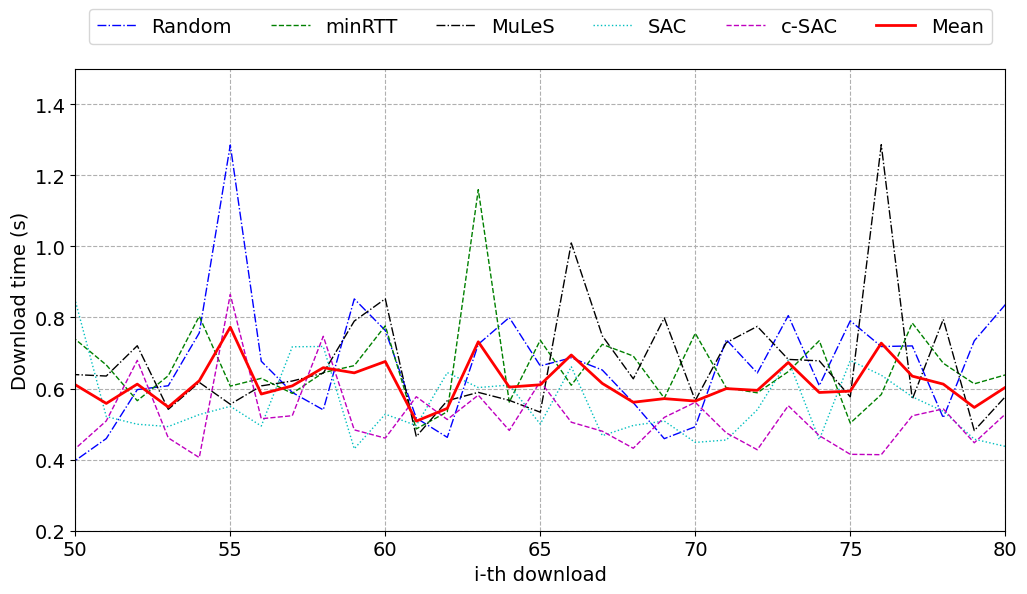

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Assuming the file paths for the five files are the same for demonstration
file_paths = [
    '../new50/none-1-1MB-0-0-50-15-10-0.9-random-result3.csv',
    '../new50/none-1-1MB-0-0-50-15-10-0.9-rtt-result3.csv',
    '../new50/none-1-1MB-0-0-50-15-10-0.9-multiclients-result3.csv',
    '../new50/none-1-1MB-0-0-50-15-10-0.9-sac-result3.csv',
    '../new50/none-1-1MB-0-0-50-15-10-0.9-sacmulti-result3.csv'
]

# Read all the files into separate dataframes
data_frames = [pd.read_csv(file, names=['data', 'timestamp']) for file in file_paths]

# Display the head of each DataFrame to verify the structure
# for i, df in enumerate(data_frames):
#     print(f"File {i+1} head:")
#     print(df.head())

# Convert the 'data' column to numeric, handling any potential non-numeric values
for df in data_frames:
    df['data'] = pd.to_numeric(df['data'], errors='coerce')

# Extract the 'data' column from each DataFrame
data_frames_1 = [df['data'] for df in data_frames]

# Combine the 'data' columns into a single DataFrame
combined_data = pd.DataFrame({f'file{i+1}': df for i, df in enumerate(data_frames_1)})
combined_data = combined_data / 1000  # Convert to seconds
# Calculate the mean of the 5 lines at each point
combined_data['mean'] = combined_data.mean(axis=1)

# Display the combined dataframe
# print(combined_data.head())

# Apply smoothing using Savitzky-Golay filter
# window_size = 2  # Window size for the filter
# poly_order = 1  # Polynomial order for the filter
# for column in combined_data.columns:
#     combined_data[column] = savgol_filter(combined_data[column], window_size, poly_order)

# Plot the combined data
plt.rcParams.update({'font.size': 14, 'font.family': 'sans-serif'})
plt.figure(figsize=(12, 6))
legend_names = ['Random', 'minRTT', 'MuLeS', 'SAC', 'c-SAC', 'Mean']
line_styles = ['-.', '--', '-.', ':', '--', '-']
colors = ['b', 'g', 'k', 'c', 'm', 'r']
line_widths = [1, 1, 1, 1, 1, 2]

for column, name, style, color, lw in zip(combined_data.columns, legend_names, line_styles, colors, line_widths):
    plt.plot(combined_data[column], label=name, linestyle=style, color=color, linewidth=lw)

plt.xlabel('i-th download')
plt.ylabel('Download time (s)')
# plt.title('Plot of 5 CSV Files')
plt.xlim(50,80)
# plt.xticks(range(1, 21))
plt.ylim(0.2,1.5)
plt.legend()
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6)
plt.grid(True, linestyle = "--")
plt.show()


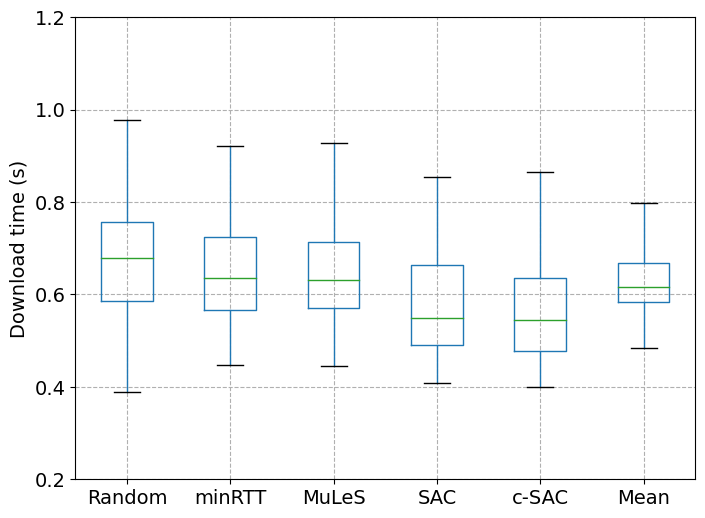

In [6]:
# Define custom x-tick labels
x_tick_labels = ['Random', 'minRTT', 'MuLeS', 'SAC', 'c-SAC', 'Mean']

# Plot the boxplot
plt.figure(figsize=(8, 6))
boxplot = combined_data.boxplot(patch_artist=False, showfliers=False)
# plt.xlabel('Client')
plt.ylabel('Download time (s)')
# plt.title('c-SAC')
plt.grid(True, linestyle="--")

# Set custom x-tick labels
plt.xticks(ticks=range(1, len(x_tick_labels) + 1), labels=x_tick_labels)
plt.ylim(0.2,1.2)

plt.show()